In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import scipy.sparse as sp
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load the train and test data
train_df = pd.read_csv("/work/outputs/train.csv")
test_df = pd.read_csv("/work/outputs/test.csv")

text_col = "clean_text"
numeric_cols = [
    "char_count",
    "word_count",
    "has_link",
    "has_mention",
    "has_hashtag",
    "is_retweet",
    "exclamation_count",
    "question_count",
    "sent_neg",
    "sent_neu",
    "sent_pos",
    "sent_compound"
]

# separate by text and numeric features
X_train_text = train_df[text_col]
X_test_text = test_df[text_col]

X_train_num = train_df[numeric_cols]
X_test_num = test_df[numeric_cols]

# Labels
y_train = train_df["label"]
y_test = test_df["label"]

In [3]:
train_df.head()

,text,label,clean_text,char_count,word_count,has_link,has_mention,has_hashtag,is_retweet,exclamation_count,question_count,sent_neg,sent_neu,sent_pos,sent_compound
0,@Cobysavage17 bet you I'll knock yo ass out,sob,bet you i'll knock yo ass out,44,7,False,True,False,False,0,0,0.368,0.632,0.000,-0.5423
1,@mollyralvis bet she came home just to see me,smirk,bet she came home just to see me,46,8,False,True,False,False,0,0,0.000,1.000,0.000,0.0000
2,I think I'm getting my sugar rush from the Sta...,flushed,i think i'm getting my sugar rush from the sta...,66,12,False,False,False,False,0,0,0.000,0.826,0.174,0.2732
3,@jackgilinsky @ShawnMendes I wish I was there ...,sob,i wish i was there but i bet he did amazing im...,90,16,False,True,False,False,1,0,0.000,0.462,0.538,0.9125
4,RT @_MeganLambert: I can't wait until I can dr...,yum,i can't wait until i can drive bcos that means...,108,18,False,True,False,True,0,0,0.000,0.857,0.143,0.3612


In [4]:
# Encoding and Vectorization
# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_text_vec = vectorizer.fit_transform(X_train_text)
X_test_text_vec = vectorizer.transform(X_test_text)

# Scale numeric features so that features with a large range do not dominate those with a small range
scaler = StandardScaler(with_mean=False)
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Convert numeric features to sparse matrices
X_train_num_sparse = sp.csr_matrix(X_train_num_scaled)
X_test_num_sparse = sp.csr_matrix(X_test_num_scaled)

# Combine text with numeric features
X_train_final = sp.hstack([X_train_text_vec, X_train_num_sparse])
X_test_final = sp.hstack([X_test_text_vec, X_test_num_sparse])

In [9]:
# MODEL 1 - SVM with GridSearchCV
svm_model = LinearSVC(max_iter=5000)

# param_grid will be the grid of parameters to search over.
# C is the regularization parameter. 
#   Small C means STRONGER regularization -> simpler model that reduces overfitting (may risk underfitting though)
#   Large C means WEAKER regularization -> more complicated model (may risk overfitting)
# class_weight is used to handle class imbalance. 
#  Need this because the 10 labels/emojis don't have equal number of tweets
# loss is the loss function we use to penalize errors. squared_hinge penalizes errors more

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "class_weight": [None, "balanced"]
}

# grid search just finds the best combination of parameters.
# use f1_macro for performance eval because we want performance across all emojis, not just the biggest class.
#.    computes F1 for each class -> averages them equally. better than pure accuracy when class sizes differ.



grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=3,
    scoring={
        "f1_macro": "f1_macro",
        "accuracy": "accuracy"
    },
    refit="f1_macro",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

# Fit grid search on training data subset to reduce running time
X_small = X_train_final[:20000]
y_small = y_train[:20000]
grid_search.fit(X_small, y_small)

# Best model from training
best_svm = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Macro F1:", grid_search.best_score_)

# Test
y_pred = best_svm.predict(X_test_final)

test_acc = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:", f"{test_acc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
[CV] END ..........................C=0.01, class_weight=None; total time=   0.9s
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
[CV] END ..........................C=0.01, class_weight=None; total time=   2.0s
/root/venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning:

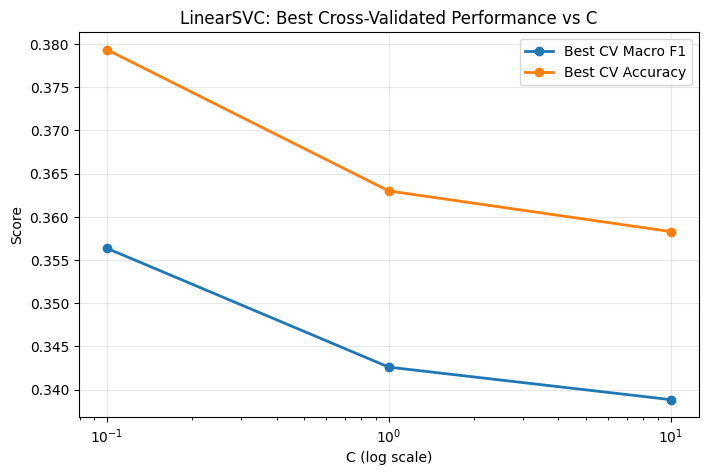

In [6]:
# GRAPH 1: Best validation Macro F1 and Accuracy by C
# For each C, keep the best score across class_weight options
# Shows the best accuracy and f1 at each C

results = pd.DataFrame(grid_search.cv_results_)

# Make C numeric so sorting/plotting works properly
results["param_C"] = results["param_C"].astype(float)

best_f1_per_C = (results.groupby("param_C", as_index=False)["mean_test_f1_macro"]
    .max()
    .sort_values("param_C")
)

best_acc_per_C = (results.groupby("param_C", as_index=False)["mean_test_accuracy"]
    .max()
    .sort_values("param_C")
)

plt.figure(figsize=(8, 5))
plt.plot(
    best_f1_per_C["param_C"],
    best_f1_per_C["mean_test_f1_macro"],
    marker="o",
    linewidth=2,
    label="Best CV Macro F1"
)
plt.plot(
    best_acc_per_C["param_C"],
    best_acc_per_C["mean_test_accuracy"],
    marker="o",
    linewidth=2,
    label="Best CV Accuracy"
)
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Score")
plt.title("LinearSVC: Best Cross-Validated Performance vs C")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

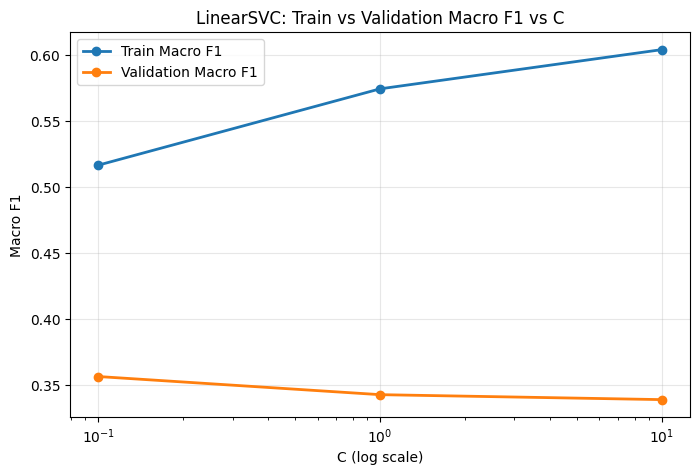

In [7]:
# GRAPH 2: Train vs Validation Macro F1 by C
# For each C, pick the row with the best validation macro F1
# Then plot that row's train and validation macro F1
# This is used to see if the model is under/overfitting

best_rows = results.loc[
    results.groupby("param_C")["mean_test_f1_macro"].idxmax()
].copy()

best_rows["param_C"] = best_rows["param_C"].astype(float)
best_rows = best_rows.sort_values("param_C")

plt.figure(figsize=(8, 5))
plt.plot(
    best_rows["param_C"],
    best_rows["mean_train_f1_macro"],
    marker="o",
    linewidth=2,
    label="Train Macro F1"
)
plt.plot(
    best_rows["param_C"],
    best_rows["mean_test_f1_macro"],
    marker="o",
    linewidth=2,
    label="Validation Macro F1"
)
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Macro F1")
plt.title("LinearSVC: Train vs Validation Macro F1 vs C")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=62b91583-1382-466d-9446-3dc5e725c312' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>